In [29]:
### using cv and dl
import torch            #numpy + dl
import torchvision

from torchvision import transforms        #converting raw img to tensors, resized images, normalized inputes
from torchvision import models

from PIL import Image

import matplotlib.pyplot as plt

In [30]:
#raw image in format jpg/png is preprocessed
#img : resize : tensor, normalize(0,1) : return processed tensor, ready for cnn
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [31]:
#ResNet-50 deep cnn, already trained
#loading previously trained data
resnet_model = models.resnet50(pretrained=True)

for nn_weights in resnet_model.parameters() :
  nn_weights.requires_grad = False

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [32]:
#img : conv layer : residual block(ReLu) : pooling : final connected layer

#.children all major layers extracted
layers = list(resnet_model.children())[:-1]

#neural network where layers are run one after another
feature_extractor = torch.nn.Sequential(*layers)

In [33]:
from google.colab import files
uploaded_image = files.upload()

Saving test.jpg to test (1).jpg


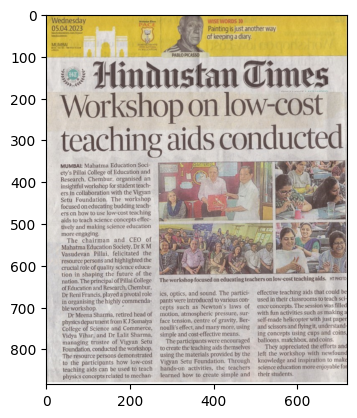

In [34]:
image = Image.open("test.jpg").convert("RGB")
plt.imshow(image)

In [35]:
#obtaining tensor of image
tensor_image = transform(image)
tensor_image = tensor_image.unsqueeze(0)

#(3,224,224) rgb channel, resized image
print(tensor_image.shape)

torch.Size([1, 3, 224, 224])


In [36]:
#extracting all the major extracted layers
with torch.no_grad() :
  image_features = feature_extractor(tensor_image)

print(image_features.shape)

torch.Size([1, 2048, 1, 1])


In [37]:
#flattening and obtaining feature vectors of the image
image_features = image_features.view(-1)

print(image_features.shape)

torch.Size([2048])


In [38]:
#converting image features from tensor to numpy
image_features_numpy = image_features.numpy()
print(image_features_numpy.shape)

(2048,)


In [39]:
#applying tf-idf

#feature_vector = X_train_tfidf[0].toarray().flatten()
from sklearn.feature_extraction.text import TfidfVectorizer

#this is only placeholder text used to demonstrate multimodal fusion
#in final project this has been replaced by actual news article text
sample_text = """
Breaking news scientists discovered a shocking hidden conspiracy related to fake reports online
"""
tfidf_vectorizer = TfidfVectorizer()

text_tfidf = tfidf_vectorizer.fit_transform([sample_text])
feature_vector = text_tfidf.toarray().flatten()

print(feature_vector.shape)

(12,)


In [40]:
#MULTIMODAL FUSION

print("Text Feature Shape :", feature_vector.shape)

print("Image Feature Shape :", image_features_numpy.shape)

Text Feature Shape : (12,)
Image Feature Shape : (2048,)


In [41]:
#created a single multimodal represntation, containing text info and image info

#peformed multimodal fusion by concatenating text feature vector and image fature vector
import numpy as np
multimodel_vector = np.concatenate([feature_vector, image_features_numpy])
print("Combined Multimodal vector shape: " , multimodel_vector.shape)

Combined Multimodal vector shape:  (2060,)


In [42]:
#now converting this used vector to tensor

multimodal_tensor = torch.tensor(multimodel_vector , dtype=torch.float32)
print(multimodal_tensor.shape)

torch.Size([2060])


In [43]:
multimodal_tensor = multimodal_tensor.unsqueeze(0)

print(multimodal_tensor.shape)

torch.Size([1, 2060])


In [44]:
#sequential series of fc, non linear activation, dropout regularization
#linear compresses 2061 features to 512
#drop out sets 30 percent neurons to zero to reduce overfitting
input_size = multimodel_vector.shape[0]
fusion_classifier = torch.nn.Sequential(
    torch.nn.Linear(input_size, 512),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(512, 128),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),
    torch.nn.Linear(128, 2)
)

In [48]:
#fusion classifier has not been trained
#predictions below are generate by using randomly initialized weights
output = fusion_classifier(multimodal_tensor)
print(output)

tensor([[-0.0080, -0.0644]], grad_fn=<AddmmBackward0>)


In [46]:
print(output.shape)

torch.Size([1, 2])


In [49]:
prediction = torch.argmax(output, dim=1)

if ( prediction.item() == 0 ) :
    print("Predicted Class : 0 , Fake")

else :
    print("Predicted Class : 1 , Real")

Predicted Class : 0 , Fake
